In [1]:
import pandas as pd

In [2]:
df_smell = pd.read_csv('./df_new_all_lemma.tsv', sep='\t', on_bad_lines='skip')

/var/folders/j8/2fw1pn3n4zb1y5l8gt8s56dc0000gn/T/ipykernel_78685/16381803.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_smell = pd.read_csv('./df_new_all_lemma.tsv', sep='\t', on_bad_lines='skip')


In [5]:
df_smell.head()

,Numb,Book,Smell_Word,Smell_Source,Quality,Odour_Carrier,Evoked_Odorant,Location,Perceiver,Time,Circumstances,Effect,SentenceBefore,Sentence,SentenceAfter,year
0,0,bl11,fmell,twenty,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,leo .,"' twenty ponnd , go fmell ' em .",lieu .,1697.0
1,1,bl11,fmell,nothing,NaN,NaN,NaN,NaN,|,NaN,NaN,NaN,lieu .,"alas sir , take fuch cold , fmell nothing .",leo .,1697.0
2,2,bl11,fmell,rafcal,rank,NaN,like tyre jade,NaN,NaN,NaN,NaN,NaN,leo .,"fmell rafcal , rank rafcall : fye , ftink , ft...",2 gent .,1697.0
3,3,bl11,fmell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sir ? leo .,", sir , fmell ? 2 gent .",smell ? lieu .,1697.0
4,4,bl11,smell,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,", sir , fmell ? 2 gent .",smell ? lieu .,muft endure .,1697.0


In [6]:
label_cols = [
    'Smell_Word',
    'Smell_Source',
    'Quality',
    'Odour_Carrier',
    'Evoked_Odorant',
    'Location',
    'Perceiver',
    'Time',
    'Circumstances',
    'Effect'
]

freq = {}

for col in label_cols:
    freq[col] = (
        df_smell[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .ne('')
        .sum()
    )

print(pd.Series(freq))

Smell_Word        2342040
Smell_Source      1498644
Quality           1729041
Odour_Carrier      153204
Evoked_Odorant      92625
Location           120772
Perceiver          132954
Time                66248
Circumstances      200789
Effect              92864
dtype: int64


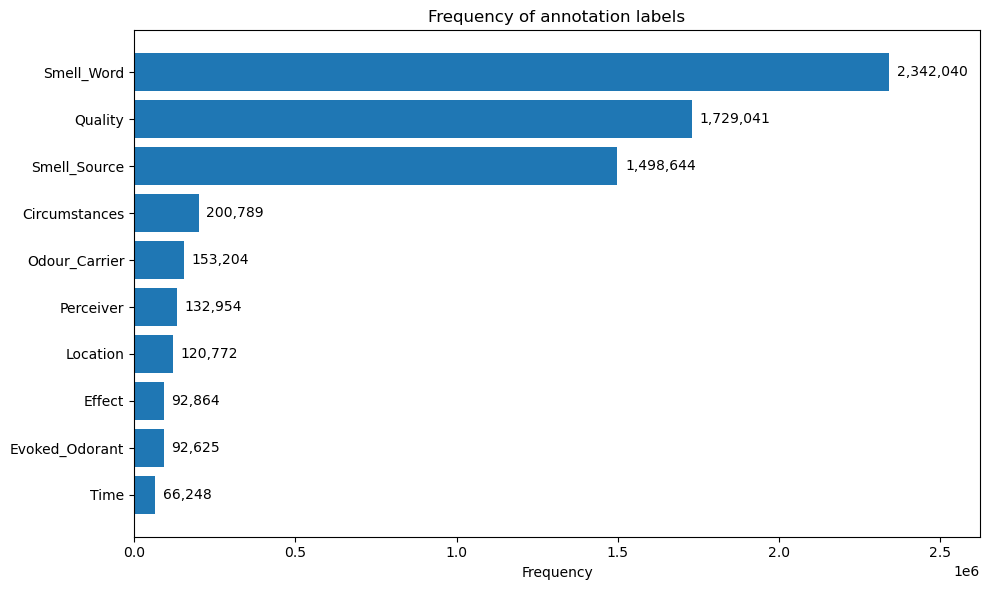

In [7]:
import matplotlib.pyplot as plt

freq = {}

for col in label_cols:
    freq[col] = (
        df_smell[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .ne('')
        .sum()
    )

freq = pd.Series(freq).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(freq.index, freq.values)


for bar, value in zip(bars, freq.values):
    plt.text(
        bar.get_width() + freq.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center'
    )

plt.xlabel('Frequency')
plt.ylabel('')
plt.title('Frequency of annotation labels')
plt.xlim(0, freq.max() * 1.12)
plt.tight_layout()
plt.show()

In [8]:
for col in label_cols:
    print(f"\n[[{col}]]")
    print(
        df_smell[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .value_counts()
    )
print(label_cols)


[[Smell_Word]]
Smell_Word
smell                      428386
odour                      297406
aromatic                   185863
fragrant                   153885
perfume                    145052
                            ...  
perfume fcent                   1
intoxicate intoxicating         1
stench taint                    1
e k                             1
savourie                        1
Name: count, Length: 12272, dtype: int64

[[Smell_Source]]
Smell_Source
                                   155642
flower                              39628
oil                                 15756
plant                               11380
water                               10004
                                    ...  
miscellaneous plant                     1
fungous vegetable                       1
grass leaf bloom                        1
linoleum mildew rotten woodwork         1
concreman -                             1
Name: count, Length: 281841, dtype: int64

[[Quality]]
Quality
ar

In [9]:
label_counts = (
    df_smell[label_cols]
    .melt(var_name='category', value_name='label')
    .dropna(subset=['label'])
)

label_counts['label'] = label_counts['label'].astype(str).str.split('|')
label_counts = label_counts.explode('label')
label_counts['label'] = label_counts['label'].str.strip()

label_counts = (
    label_counts
    .groupby(['category', 'label'])
    .size()
    .reset_index(name='frequency')
    .sort_values('frequency', ascending=False)
)

print(label_counts)

             category                 label  frequency
597277     Smell_Word                 smell     428386
594692     Smell_Word                 odour     297406
587827     Smell_Word              aromatic     185863
249338        Quality              aromatic     184598
265687        Quality              fragrant     164440
...               ...                   ...        ...
19420   Circumstances         dip hartshorn          1
250669        Quality             bifurcate          1
250665        Quality          bifagreeable          1
250664        Quality                  bieh          1
305853   Smell_Source  ' flowerin ' heather          1

[611707 rows x 3 columns]


In [10]:
df_smell['Book'].str[:2].value_counts()

Book
gu    1005169
bl     345903
ee      82435
wi      80153
ge      34448
lp       6667
ec       6089
Name: count, dtype: int64

In [13]:
df_smell['year'] = df_smell['year'].astype(str).str.extract(r'(\d{4})').squeeze()
df_smell['year'] = pd.to_numeric(df_smell['year'], errors='coerce')

df_smell = df_smell[df_smell['year'].between(1600, 1999)]

df_smell['century'] = (df_smell['year'] // 100) * 100

df_smell['century'].value_counts().sort_index()

century
1600      83294
1700     101660
1800    1046299
1900     290078
Name: count, dtype: int64

In [14]:
df_smell['century'] = ((df_smell['year'] - 1) // 100 + 1)

df_smell['corpus'] = df_smell['Book'].str[:2]
result = df_smell.groupby(['corpus', 'century']).size().unstack(fill_value=0)
print(result)

century   16     17     18      19      20
corpus                                    
bl         0   1497   7745  336625       0
ee       369  72342     14       3       3
ge         0    262    578   17700   15885
gu        19   9649  95251  667073  224702
lp         0      0      0    3199    3468
wi         0    567   1034   28975   34371


In [15]:
df_smell['year'] = df_smell['year'].astype(str).str.extract(r'(\d{4})').squeeze()
df_smell['year'] = pd.to_numeric(df_smell['year'], errors='coerce')

df_smell['century'] = ((df_smell['year'] // 100) * 100).astype('Int64')

df_smell['tokens'] = df_smell['Sentence'].str.split().str.len()

centuries = [1600, 1700, 1800, 1900]
df_filtered = df_smell[df_smell['century'].isin(centuries)]

by_century = df_filtered.groupby('century').agg(
    documents=('Numb', 'count'),
    tokens=('tokens', 'sum')
)

df_filtered['corpus'] = df_filtered['Book'].str[:2]

by_corpus_century = df_filtered.groupby(['corpus', 'century']).agg(
    documents=('Numb', 'count'),
    tokens=('tokens', 'sum')
).unstack('century')

print(by_century)
print(by_corpus_century)

         documents    tokens
century                     
1600         83294   3831393
1700        101660   3563018
1800       1046299  29881592
1900        290078   9342980
        documents                                  tokens             \
century      1600     1700      1800      1900       1600       1700   
corpus                                                                 
bl         1471.0   7055.0  337341.0       NaN    46742.0   323493.0   
ee        71645.0   1080.0       3.0       3.0  3318737.0    50361.0   
ge          262.0    484.0   17314.0   16365.0    14129.0    16941.0   
gu         9372.0  92075.0  660158.0  235089.0   431882.0  3127848.0   
lp            NaN      NaN    3106.0    3561.0        NaN        NaN   
wi          544.0    966.0   28377.0   35060.0    19903.0    44375.0   

                                
century        1800       1900  
corpus                          
bl       11190937.0        NaN  
ee             82.0      297.0  
ge         6

In [16]:
def count_types(sentences):
    words = ' '.join(sentences.dropna()).split()
    return len(set(words))

by_century = df_filtered.groupby('century').agg(
    documents=('Numb', 'count'),
    tokens=('tokens', 'sum'),
    types=('Sentence', count_types)
)

by_corpus_century = df_filtered.groupby(['corpus', 'century']).agg(
    documents=('Numb', 'count'),
    tokens=('tokens', 'sum'),
    types=('Sentence', count_types)
).unstack('century')

print(by_century)
print(by_corpus_century)

         documents    tokens   types
century                             
1600         83294   3831393  165000
1700        101660   3563018  182485
1800       1046299  29881592  461446
1900        290078   9342980  215655
        documents                                  tokens             \
century      1600     1700      1800      1900       1600       1700   
corpus                                                                 
bl         1471.0   7055.0  337341.0       NaN    46742.0   323493.0   
ee        71645.0   1080.0       3.0       3.0  3318737.0    50361.0   
ge          262.0    484.0   17314.0   16365.0    14129.0    16941.0   
gu         9372.0  92075.0  660158.0  235089.0   431882.0  3127848.0   
lp            NaN      NaN    3106.0    3561.0        NaN        NaN   
wi          544.0    966.0   28377.0   35060.0    19903.0    44375.0   

                                   types                                
century        1800       1900      1600      1700      

In [17]:
df_taste = pd.read_csv('./df_taste_total.tsv', sep='\t', on_bad_lines='skip')

In [19]:
label_cols = [
    'Taste_Word',
    'Taste_Source',
    'Quality',
    'Taste_Carrier',
    'Evoked_Taste',
    'Taste_Modifier',
    'Taster',
    'Location',
    'Circumstances',
    'Effect'
]

freq = {}

for col in label_cols:
    freq[col] = (
        df_taste[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .ne('')
        .sum()
    )

print(pd.Series(freq))

Taste_Word        449293
Taste_Source      268393
Quality           215412
Taste_Carrier      11597
Evoked_Taste        6892
Taste_Modifier     23091
Taster            111696
Location           11072
Circumstances      44040
Effect             12071
dtype: int64


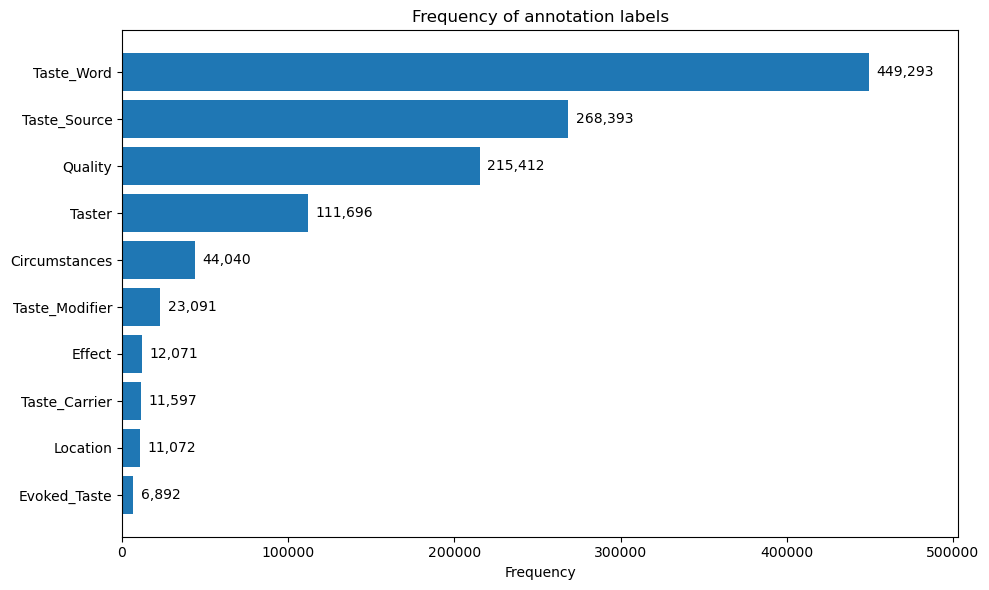

In [20]:
import matplotlib.pyplot as plt

freq = {}

for col in label_cols:
    freq[col] = (
        df_taste[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .ne('')
        .sum()
    )

freq = pd.Series(freq).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(freq.index, freq.values)


for bar, value in zip(bars, freq.values):
    plt.text(
        bar.get_width() + freq.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center'
    )

plt.xlabel('Frequency')
plt.ylabel('')
plt.title('Frequency of annotation labels')
plt.xlim(0, freq.max() * 1.12)
plt.tight_layout()
plt.show()

In [21]:
for col in label_cols:
    print(f"\n[[{col}]]")
    print(
        df_taste[col]
        .dropna()
        .astype(str)
        .str.split('|')
        .explode()
        .str.strip()
        .value_counts()
    )
print(label_cols)


[[Taste_Word]]
Taste_Word
eat                    66140
taste                  45423
drink                  41938
sweet                  32732
bitter                 20391
                       ...  
flocktaste                 1
bitter Sower               1
disgorging unsavory        1
drinktaste bitter          1
palateableness             1
Name: count, Length: 4197, dtype: int64

[[Taste_Source]]
Taste_Source
it                            5141
them                          2027
water                         2021
bread                         1880
wine                          1868
                              ... 
a good and competent dyner       1
all such wynes                   1
TRiacle Mustard seed             1
Seeds of Withiwind               1
piece of roast meat              1
Name: count, Length: 107177, dtype: int64

[[Quality]]
Quality
sweet                    30504
bitter                   19080
delicious                 9600
seasoned                  5468
sour       

In [22]:
label_counts = (
    df_taste[label_cols]
    .melt(var_name='category', value_name='label')
    .dropna(subset=['label'])
)

label_counts['label'] = label_counts['label'].astype(str).str.split('|')
label_counts = label_counts.explode('label')
label_counts['label'] = label_counts['label'].str.strip()

label_counts = (
    label_counts
    .groupby(['category', 'label'])
    .size()
    .reset_index(name='frequency')
    .sort_values('frequency', ascending=False)
)

print(label_counts)

            category                               label  frequency
177950    Taste_Word                                 eat      66140
179964    Taste_Word                               taste      45423
177784    Taste_Word                               drink      41938
179637    Taste_Word                               sweet      32732
54078        Quality                               sweet      30504
...              ...                                 ...        ...
78965   Taste_Source                    Meat Substitutes          1
78966   Taste_Source                        Meat extract          1
78967   Taste_Source     Meat forbidden by Moses ' s Law          1
78968   Taste_Source  Meat forbidden by the Law of Moses          1
212948        Taster                                   ■          1

[212949 rows x 3 columns]


In [23]:
df_taste['Book'].str[:2].value_counts()

Book
gu    105521
ee     89491
ec     32038
bl     18311
wk     17479
lp      6957
ob      5145
Bo         1
Name: count, dtype: int64

In [24]:
df_taste['year'] = df_taste['year'].astype(str).str.extract(r'(\d{4})').squeeze()
df_taste['year'] = pd.to_numeric(df_taste['year'], errors='coerce')

df_taste = df_taste[df_taste['year'].between(1600, 1999)]

df_taste['century'] = (df_taste['year'] // 100) * 100
df_taste['century'].value_counts().sort_index()

century
1600.0     1728
1700.0     5599
1800.0    65347
1900.0    57753
Name: count, dtype: int64

In [25]:
df_taste['century'] = ((df_taste['year'] - 1) // 100 + 1)

df_taste['corpus'] = df_taste['Book'].str[:2]
result = df_taste.groupby(['corpus', 'century']).size().unstack(fill_value=0)
print(result)

century  17.0  18.0   19.0   20.0
corpus                           
gu       1625  2573  58559  42697
lp          0     0   1216   5741
ob          0  3006    406      0
wk        119   192   6732   7561


In [26]:
df_taste['year'] = df_taste['year'].astype(str).str.extract(r'(\d{4})').squeeze()
df_taste['year'] = pd.to_numeric(df_taste['year'], errors='coerce')

df_taste['century'] = ((df_taste['year'] // 100) * 100).astype('Int64')

df_taste['tokens'] = df_taste['Sentence'].str.split().str.len()

centuries = [1600, 1700, 1800, 1900]
df_filtered = df_taste[df_taste['century'].isin(centuries)]

by_century = df_filtered.groupby('century').agg(
    documents=('Book','count'),
    tokens=('tokens', 'sum')
)

df_filtered['corpus'] = df_filtered['Book'].str[:2]

by_corpus_century = df_filtered.groupby(['corpus', 'century']).agg(
    documents=('Book', 'count'),
    tokens=('tokens', 'sum')
).unstack('century')

print(by_century)
print(by_corpus_century)

         documents   tokens
century                    
1600          1728   111644
1700          5599   486504
1800         65347  3044532
1900         57753  2356456
        documents                              tokens                       \
century      1600    1700     1800     1900      1600      1700       1800   
corpus                                                                       
gu         1625.0  2445.0  57166.0  44218.0  105359.0  141066.0  2634905.0   
lp            NaN     NaN   1147.0   5810.0       NaN       NaN    57668.0   
ob            NaN  2971.0    441.0      NaN       NaN  331810.0    46001.0   
wk          103.0   183.0   6593.0   7725.0    6285.0   13628.0   305958.0   

                    
century       1900  
corpus              
gu       1677396.0  
lp        400709.0  
ob             NaN  
wk        278351.0  


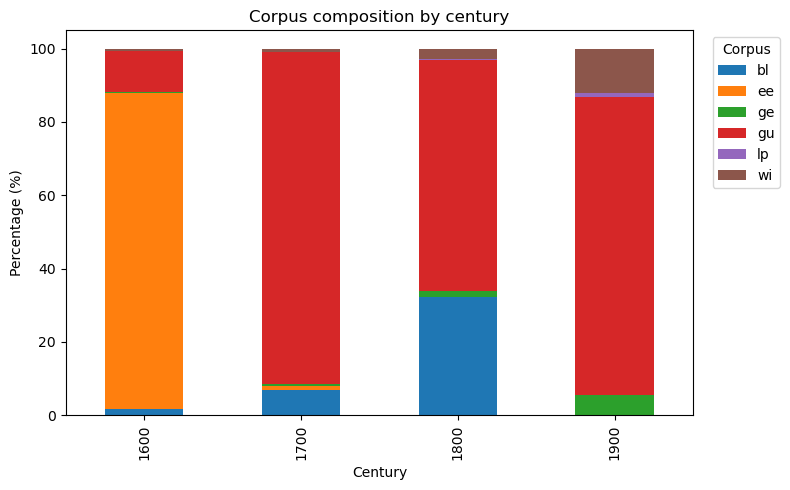

In [ ]:
#SMELL

df_smell = df_smell[
    df_smell['century'].between(1600, 2000)
].copy()

df = pd.crosstab(
    df_smell['century'],
    df_smell['corpus']
)

pct = df.div(df.sum(axis=1), axis=0) * 100

pct.index = [
    f'{int(c)//100}00'
    for c in pct.index
]

ax = pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Century')
ax.set_title('Corpus composition by century')

ax.legend(
    title='Corpus',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

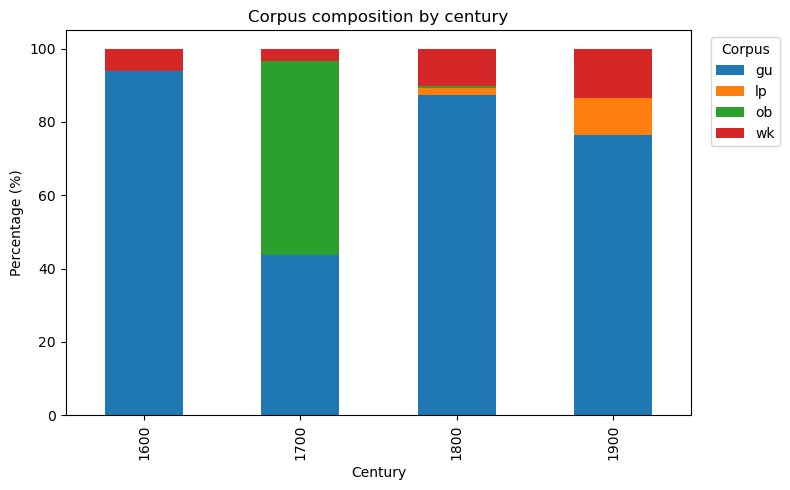

In [30]:
#TASTE

df_taste = df_taste[
    df_taste['century'].between(1600, 2000)
].copy()

df = pd.crosstab(
    df_taste['century'],
    df_taste['corpus']
)

pct = df.div(df.sum(axis=1), axis=0) * 100

pct.index = [
    f'{int(c)//100}00'
    for c in pct.index
]

ax = pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Century')
ax.set_title('Corpus composition by century')

ax.legend(
    title='Corpus',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [31]:
import seaborn as sns

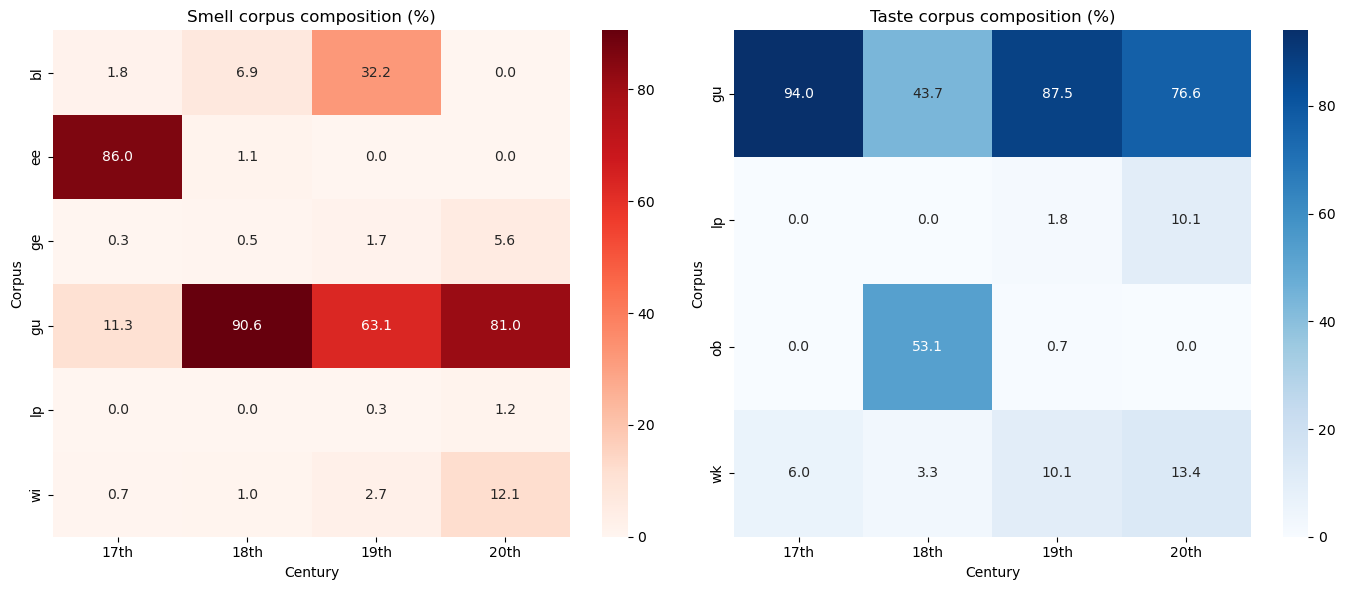

In [32]:
def get_corpus_pct(df):
    df = df.copy()

    df['year'] = pd.to_numeric(df['year'], errors='coerce')

    df = df[df['year'].between(1600, 1999)]

    df['century'] = (df['year'] // 100) * 100

    counts = pd.crosstab(
        df['century'],
        df['corpus']
    )

    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    pct = pct.reindex([1600, 1700, 1800, 1900], fill_value=0)

    pct.index = ['17th', '18th', '19th', '20th']

    return pct


pct_smell = get_corpus_pct(df_smell)
pct_taste = get_corpus_pct(df_taste)


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

sns.heatmap(
    pct_smell.T,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    ax=axes[0]
)

axes[0].set_xlabel("Century")
axes[0].set_ylabel("Corpus")
axes[0].set_title("Smell corpus composition (%)")


sns.heatmap(
    pct_taste.T,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_xlabel("Century")
axes[1].set_ylabel("Corpus")
axes[1].set_title("Taste corpus composition (%)")


plt.tight_layout()
plt.show()